<a href="https://colab.research.google.com/github/tort-cam/ST554HW7/blob/main/ST554HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reading in the tools we'll need

In [120]:
pip install ucimlrepo

In [121]:
## Pulling in the data
from ucimlrepo import fetch_ucirepo
## The essentials
import numpy as np
import pandas as pd
import math
## Graphing
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
## Modeling & Regression
from sklearn import linear_model
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, cross_validate
from scipy.stats import linregress
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, ElasticNetCV, ElasticNet, RidgeCV, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

### Reading in our data

In [122]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

In [123]:
wine = wine_quality.data['features'].copy()
wine['color'] = wine_quality.data['original']['color']
wine['quality'] = wine_quality.data['original']['quality']
wine['color'] = wine['color'].map({'red': 0, 'white': 1})

In [124]:
wine

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,1,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,7


## Alcohol as response

### Train and test split

Here, the "N"s on the variables mean they are unstandardized. That will come next.

In [132]:
cols = wine.columns.drop("alcohol")

x_trainN, x_testN, y_train, y_test = train_test_split(
    wine[cols],
    wine['alcohol'],
    test_size = .2,
    random_state = 9,
    stratify = wine['color']
)

### Standardizing the training split

In [139]:
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_trainN), columns = x_trainN.columns)
x_train.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,color,quality
count,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03
mean,-1.367217e-16,1.886760e-16,6.084116e-17,3.076239e-17,1.678259e-16,1.162135e-17,9.570520e-18,3.908327e-14,3.329174e-16,-2.474663e-16,-1.032249e-16,8.886911e-17
std,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00
min,-2.655375e+00,-1.582749e+00,-2.226657e+00,-1.018009e+00,-1.302397e+00,-1.644949e+00,-1.932224e+00,-2.526757e+00,-2.960377e+00,-2.074426e+00,-1.750237e+00,-3.224840e+00
25%,-6.355791e-01,-6.720074e-01,-4.770658e-01,-7.660517e-01,-5.033603e-01,-7.518265e-01,-6.827389e-01,-7.721183e-01,-6.667797e-01,-6.714686e-01,5.713511e-01,-9.423076e-01
50%,-1.694723e-01,-3.077106e-01,-5.716387e-02,-4.930977e-01,-2.553834e-01,-8.198483e-02,3.879466e-02,6.025298e-02,-4.688844e-02,-1.370087e-01,5.713511e-01,1.989584e-01
75%,3.743190e-01,4.208830e-01,5.027054e-01,5.567254e-01,2.405704e-01,5.878569e-01,6.899347e-01,7.394679e-01,6.349919e-01,4.642587e-01,5.713511e-01,1.989584e-01
max,6.744445e+00,6.006767e+00,6.381333e+00,1.267168e+01,1.528450e+01,1.443125e+01,5.705473e+00,1.474328e+01,4.912241e+00,9.817307e+00,5.713511e-01,3.622756e+00


Below, I am just making a quick collection of every variable plotted against alcohol. This helps provide a general idea of which variables may be most useful.

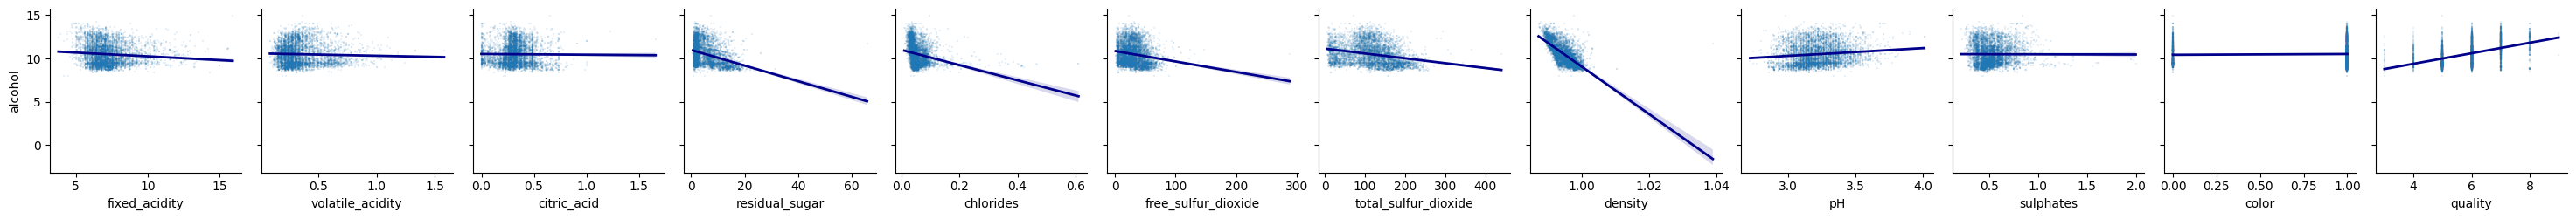

In [140]:
notB = wine.columns.drop(["alcohol"])
every = sns.pairplot(kind = "reg", data = wine, y_vars = "alcohol", x_vars = notB, markers = "+",\
                    plot_kws = {'line_kws':{'lw' : 2, 'color':"darkblue"}, 'scatter_kws':{'alpha':.1, 's':2}})

### MLR

In [141]:
poly = PolynomialFeatures(degree = 2, interaction_only = True, include_bias = False)
poly2 = PolynomialFeatures(degree = 2, include_bias = False)

pipeline = Pipeline([
    ('interactions', poly),
    ('model', LinearRegression())
])
pipeline2 = Pipeline([
    ('interactions', poly2),
    ('model', LinearRegression())
])

In [142]:
## Full Model, includes color & quality
cv_full_mlr = cross_validate(
    LinearRegression(),
    x_train,
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Medium-size model with interaction term
cv_med_int_mlr = cross_validate(
    pipeline,
    x_train[['density', 'residual_sugar', 'total_sulfur_dioxide', 'quality']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Small model with polynomial term - Chosen based on early plot
cv_small_int_mlr = cross_validate(
    pipeline2,
    x_train[['density', 'residual_sugar']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Smaller model, only includes a few variables - Chosen based on early plot
cv_small_mlr = cross_validate(
    LinearRegression(),
    x_train[['density', 'residual_sugar']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")



In [143]:
print("MLR Models RMSE:\n" +
      "Full simple model: \t"+ str(np.sqrt(-sum(cv_full_mlr['test_score']))) + "\n" +
      "Medium interaction: \t"+ str(np.sqrt(-sum(cv_med_int_mlr['test_score']))) + "\n" +
      "Small polynomial: \t"+ str(np.sqrt(-sum(cv_small_int_mlr['test_score']))) + "\n" +
      "Small: \t\t\t"+ str(np.sqrt(-sum(cv_small_mlr['test_score']))))

MLR Models RMSE:
Full simple model: 	1.1594887389353608
Medium interaction: 	1.7118070497102211
Small polynomial: 	1.6136845111301223
Small: 			1.9468913155026373


From this print statement, we can see that to no surprise, the full simple model is best. \
Let's save that one for later use.

In [144]:
best_mlr = LinearRegression().fit(x_train, y_train)

### LASSO

Similar to the last part, here I am setting up a LASSO model, and using `LassoCV` to determine the best tuning parameter (alpha) \
I've chosen `residual_sugar`, `volatile_acidity`, `total_sulfur_dioxide`, `quality`, and `density` as my 5 predictors of `alcohol`.

In [145]:
lassomodel = LassoCV(cv=5, random_state=0).fit(x_train[['residual_sugar', 'volatile_acidity', 'total_sulfur_dioxide', 'quality', 'density']], y_train)

Seems like .0008 is the best tuning parameter for this model!

In [146]:
np.set_printoptions(suppress = True)
fit_info = np.array(list(zip(lassomodel.alphas_, np.mean(lassomodel.mse_path_, axis = 1))))
print(fit_info[fit_info[:,1].argsort()][0:10,].round(5))
print("alpha for lowest MSE:\t" + str(lassomodel.alpha_))

[[0.00081 0.53102]
 [0.00087 0.53103]
 [0.00093 0.53103]
 [0.001   0.53103]
 [0.00107 0.53103]
 [0.00115 0.53104]
 [0.00123 0.53104]
 [0.00132 0.53104]
 [0.00142 0.53105]
 [0.00152 0.53105]]
alpha for lowest MSE:	0.0008120305631876538


Saving this model for later!

In [147]:
tuned_lasso = Lasso(lassomodel.alpha_).fit(x_train[['residual_sugar', 'volatile_acidity', 'total_sulfur_dioxide', 'quality', 'density']], y_train)

### Ridge Regression

Here I set up a ridge regression model.

In [148]:
ridge = RidgeCV(alphas = (range(0,100)),
                cv = 5)
ridge.fit(x_train[['fixed_acidity', 'citric_acid', 'pH', 'total_sulfur_dioxide', 'density']], y_train)
print(ridge.alpha_)

60


Seems like 60 is our best alpha value for this model! Let's save that version for later.

In [149]:
best_ridge = Ridge(alpha = ridge.alpha_)
best_ridge.fit(x_train[['fixed_acidity', 'citric_acid', 'pH', 'total_sulfur_dioxide', 'density']], y_train)

Ridge(alpha=np.int64(60))

### Elastic Net

Here I set up an Elastic Net model, again using 5 predictors. When cross validating here, I supply an list of potential `l1_ratio`s, and this method will determine which of the provided ratios is best.

In [150]:
stretch = ElasticNetCV(cv = 5,
                     l1_ratio = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.96, 0.98, 0.99, 1])
stretch.fit(x_train[['fixed_acidity', 'chlorides', 'residual_sugar', 'sulphates', 'color']], y_train)
print(stretch.alpha_, stretch.l1_ratio_)

0.010931912584990391 0.1


Looks like the model fits best at alpha of .011 and l1 ratio of .1.

In [151]:
best_EN = ElasticNet(alpha = stretch.alpha_, l1_ratio = stretch.l1_ratio_)
best_EN.fit(x_train[['fixed_acidity', 'chlorides', 'residual_sugar', 'sulphates', 'color']], y_train)

ElasticNet(alpha=np.float64(0.010931912584990391), l1_ratio=np.float64(0.1))

### Model Testing

Before Testing out models here, we must first standardize the test set data, based on the values from the training set. \
Here we see that our means are *pretty close* to 0, and our standard deviations are *pretty close* to 1, though not as close as they were on our training set. This makes sense given it's based on our training set.

In [152]:
x_test = pd.DataFrame(scaler.transform(x_testN), columns = x_testN.columns)
x_test.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,color,quality
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,-0.011056,-0.030775,0.016265,-0.005503,-0.032353,0.015786,-0.004484,-0.003991,0.029024,0.025385,-0.000117,-0.041585
std,1.035106,0.997663,1.082189,0.994829,0.811136,0.952865,0.973164,0.991985,0.983073,0.970048,1.000454,0.982259
min,-2.344637,-1.582749,-2.226657,-0.976016,-1.219738,-1.589129,-1.914626,-2.410225,-3.084355,-2.007618,-1.750237,-3.224840
25%,-0.635579,-0.732724,-0.547049,-0.766052,-0.503360,-0.751827,-0.667340,-0.832049,-0.666780,-0.671469,0.571351,-0.942308
50%,-0.169472,-0.307711,-0.057164,-0.556087,-0.255383,-0.081985,0.038795,0.083559,-0.046888,-0.137009,0.571351,0.198958
75%,0.374319,0.360167,0.572689,0.556725,0.268123,0.643677,0.742730,0.779422,0.634992,0.531066,0.571351,0.198958
max,6.045285,7.524671,9.390630,4.325590,8.368702,3.769605,2.537765,2.993529,3.362513,7.078200,0.571351,3.622756


First, I am testing based on RMSE, taking the `mean_squared_error`, and using `np.sqrt()` to return this value. \
Second, I am testing based on MAE, taking the `mean_absolute_error`. \
<br>
Through both metrics, the full MLR model is best by a wide margin, with the LASSO and Ridge models fitting about equal to each other.

In [153]:
MLR = best_mlr.predict(x_test)
LASSO = tuned_lasso.predict(x_test[['residual_sugar', 'volatile_acidity', 'total_sulfur_dioxide', 'quality', 'density']])
RIDGE = best_ridge.predict(x_test[['fixed_acidity', 'citric_acid', 'pH', 'total_sulfur_dioxide', 'density']])
EN = best_EN.predict(x_test[['fixed_acidity', 'chlorides', 'residual_sugar', 'sulphates', 'color']])

print(" Model \t RMSE \t\t\t MAE \n",

      "MLR \t", np.sqrt(mean_squared_error(y_test,MLR)),"\t",
        mean_absolute_error(y_test,MLR) , "\n" ,

      "LASSO \t", np.sqrt(mean_squared_error(y_test,LASSO)),"\t",
        mean_absolute_error(y_test,LASSO), "\n" ,

      "RIDGE \t", np.sqrt(mean_squared_error(y_test,RIDGE)),"\t",
        mean_absolute_error(y_test,RIDGE), "\n" ,

      "EN \t", np.sqrt(mean_squared_error(y_test,EN)),"\t",
        mean_absolute_error(y_test,EN))

 Model 	 RMSE 			 MAE 
 MLR 	 0.465313441450464 	 0.3532999763427778 
 LASSO 	 0.7207570271254976 	 0.5659253062120058 
 RIDGE 	 0.7342792074412888 	 0.5788971766994361 
 EN 	 1.0370458878929019 	 0.8464594645168972


## Wine Type as Response

This section is similar to the work done above, but now using **Wine Type** (a value of either 1 or 0) as our response variable.